# Supply Chain Delivery Performance and Delay-Risk Analysis

## Business Objective
Analyze historical supply-chain delivery records to identify delivery delays, quantify their operational and financial impact, and prioritize countries, vendors, and high-risk delivery events for corrective action.

## Key Questions

1. What is the overall On-Time Delivery performance?
2. Which countries have the highest delay rates, cumulative late days, and shipment-value exposure?
3. Which vendors contribute most to delivery-delay impact and reliability risk?
4. Are multi-site delivery events associated with increased late-delivery risk?
5. What operational actions should be prioritized to reduce delay exposure?

## Tools
Python, pandas, NumPy, Matplotlib/Seaborn, data cleaning, KPI design, and exploratory analysis.

> Dataset note: This project uses historical/publicly available data for portfolio and educational purposes.

In [362]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

## Loading the Data

### Dataset Source and Scope

The dataset contains historical commodity-shipment records for anti-retroviral treatments and rapid test kits delivered to PEPFAR-supported countries.

Source: [Kaggle – Supply Chain Shipment Pricing Data](https://www.kaggle.com/datasets/divyeshardeshana/supply-chain-shipment-pricing-data)

### Delivery Performance Definition

A shipment is considered **on time** when the actual delivery date is on or before the scheduled delivery date.

In [363]:
df = pd.read_csv("SCMS_Delivery_History_Dataset.csv")

## Initial Data Exploration

This section reviews the dataset structure, data types, missing values, and potential data-quality issues before preparing the data for delivery-performance analysis.

### Dataset Shape and Sample Records

In [364]:
print(f'Dataset shape: {df.shape[0]:,} rows and {df.shape[1]} columns')
df.head()

Dataset shape: 10,324 rows and 33 columns


,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN


### Data Types, Completeness, and Cardinality

In [365]:
data_types = pd.DataFrame({
    'data_type': df.dtypes.astype(str),
    'non_null_count': df.notna().sum(),
    'missing_count': df.isna().sum(),
    'unique_values': df.nunique()
})

data_types

,data_type,non_null_count,missing_count,unique_values
ID,int64,10324,0,10324
Project Code,str,10324,0,142
PQ #,str,10324,0,1237
PO / SO #,str,10324,0,6233
ASN/DN #,str,10324,0,7030
Country,str,10324,0,43
Managed By,str,10324,0,4
Fulfill Via,str,10324,0,2
Vendor INCO Term,str,10324,0,8
Shipment Mode,str,9964,360,4


### Missing-Value Assessment

In [366]:
missing_summary = (
    df.isna()
    .sum()
    .loc[lambda x: x > 0]
    .sort_values(ascending=False)
    .to_frame('missing_values')
)

missing_summary['missing_rate_%'] = (
    missing_summary['missing_values'] / len(df) * 100
).round(1)

missing_summary

,missing_values,missing_rate_%
Dosage,1736,16.8
Shipment Mode,360,3.5
Line Item Insurance (USD),287,2.8


### Mixed-Type Logistics Fields

In [367]:
mixed_value_examples = df[
    [
        'ASN/DN #',
        'Country',
        'Shipment Mode',
        'Line Item Value',
        'Weight (Kilograms)',
        'Freight Cost (USD)',
        'Line Item Insurance (USD)'
    ]
].sample(10, random_state=42)

mixed_value_examples

,ASN/DN #,Country,Shipment Mode,Line Item Value,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
6584,DN-1515,Zambia,Truck,272972.06,4959,9973.51,535.03
1692,DN-517,Ethiopia,Air,9095.00,33,755.5,14.55
2692,ASN-32122,South Africa,Truck,1246.30,Weight Captured Separately,Freight Included in Commodity Cost,1.28
7702,DN-2769,Nigeria,Air Charter,6431.94,2566,16532.5,9.02
321,ASN-1651,Mozambique,Air,42.00,Weight Captured Separately,Invoiced Separately,0.07
9750,DN-3700,Tanzania,Truck,55458.75,825,5137.06,57.01
39,ASN-3435,Côte d'Ivoire,Air,13180.00,206,2656.12,25.83
9483,DN-2281,Mozambique,Truck,451861.20,8491,10605.03,745.57
8317,DN-3642,Rwanda,Truck,325609.90,See DN-3642 (ID#:82668),See DN-3642 (ID#:82668),402.78
2613,DN-850,Mozambique,Air,46722.00,See DN-850 (ID#:10733),See DN-850 (ID#:10733),74.76


### Initial Findings

- The dataset contains 10,324 line-item records and 33 columns.
- Missing values are limited to `Dosage`, `Shipment Mode`, and `Line Item Insurance (USD)`.
- The highest missingness occurs in `Dosage` (16.8%). Based on the product information, these missing values are expected for test-kit products where dosage is not applicable.
- `Shipment Mode` is missing in 3.5% of records and will be preserved as `Unknown` rather than imputed with a transport mode.
- `Weight (Kilograms)` and `Freight Cost (USD)` contain mixed numeric and text values, so they require additional cleaning before any cost or weight analysis.
- The data is recorded at line-item level. Shipment-level delivery KPIs will therefore be calculated later by aggregating line items into delivery events.

## Data Cleaning and Preparation

### Rename selected columns

In [368]:
df.rename(columns={
    "ASN/DN #" : "delivery_notice",
    "PO / SO #": "po_so"
}, inplace=True)

### Handle missing values


Missing insurance values were retained as missing because insurance cost is not required for the initial on-time delivery analysis. 

Any future cost analysis should treat missing insurance values separately.

#### Handling Missing Shipment Modes

In [369]:
df['Shipment Mode'] = df['Shipment Mode'].fillna('Unknown')

Missing shipment-mode values were labeled as `Unknown`. This preserves the affected delivery records without making an unsupported assumption about the transport method.

#### Handling Missing Dosage

Verifying that 'Dosage' has nulls only in test kits

In [370]:
df.loc[((df["Dosage Form"] == "Test kit") | (df["Dosage Form"] == "Test kit - Ancillary")), "Dosage" ].unique()

<StringArray>
[nan]
Length: 1, dtype: str

In [371]:
df.Dosage = df.Dosage.fillna('Not applicable')

### Converting Date Realted Colums to DATETIME

In [372]:
df["Delivered to Client Date"]
df['Delivered to Client Date'] = pd.to_datetime(
    df['Delivered to Client Date'],
    format='%d-%b-%y'
).dt.date

df['Scheduled Delivery Date'] = pd.to_datetime(
    df['Scheduled Delivery Date'],
    format='%d-%b-%y'
).dt.date

df['Delivery Recorded Date'] = pd.to_datetime(
    df['Delivery Recorded Date'],
    format='%d-%b-%y'
).dt.date


df["Delivered to Client Date"] = pd.to_datetime(df["Delivered to Client Date"])
df["Scheduled Delivery Date"] = pd.to_datetime(df["Scheduled Delivery Date"])
df["delivery_recorded_date"] = pd.to_datetime(df["Delivery Recorded Date"])

# Exploring Deliveries 

## Delivery Event Construction

The raw dataset is recorded at line-item level, while delivery performance must be measured at the delivery-event level.

A delivery notice usually represents one delivery, but the same delivery notice can occasionally appear with more than one scheduled delivery date. Therefore, a delivery event is defined as:

Delivery Event Key = Delivery Notice + Scheduled Delivery Date

This approach prevents duplicate line items from inflating on-time delivery KPIs while preserving cases in which a delivery notice has multiple planned delivery dates.

### Line Items per Delivery Notice

In [373]:
lines_per_delivery = (
    df.groupby('delivery_notice')
      .size()
      .rename('line_items')
)

line_item_summary = pd.DataFrame({
    'Metric': [
        'Raw line-item records',
        'Unique delivery notices',
        'Average line items per delivery notice',
        'Median line items per delivery notice',
        'Maximum line items in one delivery notice'
    ],
    'Value': [
        f'{len(df):,}',
        f'{df["delivery_notice"].nunique():,}',
        f'{lines_per_delivery.mean():.2f}',
        f'{lines_per_delivery.median():.0f}',
        f'{lines_per_delivery.max():,}'
    ]
})

line_item_summary

,Metric,Value
0,Raw line-item records,"10,324"
1,Unique delivery notices,"7,030"
2,Average line items per delivery notice,1.47
3,Median line items per delivery notice,1
4,Maximum line items in one delivery notice,54


**Finding:** Delivery notices contain multiple line items. Therefore, using raw line-item rows for delivery KPIs would overrepresent deliveries with many product lines.

### Delivery-Event Key Validation

In [374]:
scheduled_dates_per_notice = (
    df.groupby('delivery_notice')['Scheduled Delivery Date']
      .nunique()
      .rename('scheduled_dates')
)

notices_with_multiple_dates = scheduled_dates_per_notice[
    scheduled_dates_per_notice > 1
]

delivery_key_validation = pd.DataFrame({
    'Metric': [
        'Unique delivery notices',
        'Delivery notices with one scheduled date',
        'Delivery notices with multiple scheduled dates',
        'Maximum scheduled dates for one delivery notice'
    ],
    'Value': [
        f'{len(scheduled_dates_per_notice):,}',
        f'{(scheduled_dates_per_notice == 1).sum():,}',
        f'{(scheduled_dates_per_notice > 1).sum():,}',
        f'{scheduled_dates_per_notice.max():,}'
    ]
})

delivery_key_validation

,Metric,Value
0,Unique delivery notices,"7,030"
1,Delivery notices with one scheduled date,"7,020"
2,Delivery notices with multiple scheduled dates,10
3,Maximum scheduled dates for one delivery notice,2


**Finding:** Most delivery notices have one scheduled delivery date. However, 10 delivery notices have two scheduled dates. The analysis therefore defines one delivery event by the combination of `deliverynotice` and `Scheduled Delivery Date`.

### Creating a new DF of grouped delivery events by delivery notice and schedluded delivery date

In [375]:
df["delivery_event_key"] = (
    df["delivery_notice"].astype(str)
    + "_"
    + df["Scheduled Delivery Date"].dt.strftime("%Y-%m-%d")
)

consistency_check = (
    df.groupby('delivery_event_key')
      .agg(
          delivered_dates=('Delivered to Client Date', 'nunique'),
          countries=('Country', 'nunique'),
          po_so_values=('po_so', 'nunique'),
          manufacturing_sites=('Manufacturing Site', 'nunique'),
          vendors=('Vendor', 'nunique')
      ) 
)

inconsistent_events = consistency_check[
    (consistency_check['delivered_dates'] > 1) |
    (consistency_check['countries'] > 1) |
    (consistency_check['po_so_values'] > 1) |
    (consistency_check['manufacturing_sites'] > 1) |
    (consistency_check['vendors'] > 1)
]

print(f'Inconsistent delivery events: {len(inconsistent_events):,}')



Inconsistent delivery events: 879


In [376]:
inconsistency_summary = pd.DataFrame({
    'Field': [
        'Delivered date',
        'Country',
        'PO/SO',
        'Manufacturing site',
        'Vendor'
    ],
    'Events with >1 value': [
        (consistency_check['delivered_dates'] > 1).sum(),
        (consistency_check['countries'] > 1).sum(),
        (consistency_check['po_so_values'] > 1).sum(),
        (consistency_check['manufacturing_sites'] > 1).sum(),
        (consistency_check['vendors'] > 1).sum()
    ]
})

inconsistency_summary

,Field,Events with >1 value
0,Delivered date,0
1,Country,0
2,PO/SO,0
3,Manufacturing site,879
4,Vendor,0


In [377]:
grouped_deliveries = (
    df.groupby('delivery_event_key', as_index=False)
      .agg(
          delivery_notice=('delivery_notice', 'first'),
          scheduled_delivery_date=('Scheduled Delivery Date', 'first'),
          delivered_date=('Delivered to Client Date', 'first'),
          po_so=('po_so', 'first'),
          country=('Country', 'first'),
          number_of_lines=('ID', 'count'),
          number_of_products=('Item Description', 'nunique'),
          number_of_manufacturing_sites=('Manufacturing Site', 'nunique'),
          multiple_manufacturing_sites_flag=(
              'Manufacturing Site',
              lambda x: x.nunique() > 1
          ),
          number_of_vendors=('Vendor', 'nunique'),
          shipment_value=('Line Item Value', 'sum')
      )
)

grouped_deliveries.head()

,delivery_event_key,delivery_notice,scheduled_delivery_date,delivered_date,po_so,country,number_of_lines,number_of_products,number_of_manufacturing_sites,multiple_manufacturing_sites_flag,number_of_vendors,shipment_value
0,ASN-10006_2011-04-05,ASN-10006,2011-04-05,2011-04-05,SCMS-100090,Haiti,1,1,1,False,1,1900.0
1,ASN-10007_2011-04-05,ASN-10007,2011-04-05,2011-04-05,SCMS-100140,Haiti,2,2,1,False,1,3970.0
2,ASN-10011_2011-02-09,ASN-10011,2011-02-09,2011-03-17,SCMS-91340,South Africa,1,1,1,False,1,120240.0
3,ASN-10012_2011-03-07,ASN-10012,2011-03-07,2011-03-07,SCMS-83880,South Africa,1,1,1,False,1,400800.0
4,ASN-10062_2011-04-06,ASN-10062,2011-04-06,2011-04-06,SCMS-98580,Haiti,1,1,1,False,1,195360.0


### Consistency Check Result

All delivery-critical fields are consistent within each delivery event:

- Each delivery event has one delivered date.
- Each delivery event has one destination country.
- Each delivery event has one PO/SO reference.
- Each delivery event has one vendor.

A total of 879 delivery events contain line items from more than one manufacturing site. This is expected for multi-product shipments and does not affect delivery-level on-time performance calculations.

Therefore, `delivery_notice + scheduled_delivery_date` is retained as the delivery-event key.

#### Adding Vendor Information to Delivery Events

In [378]:
grouped_deliveries = (
    df.groupby('delivery_event_key', as_index=False)
      .agg(
          delivery_notice=('delivery_notice', 'first'),
          scheduled_delivery_date=('Scheduled Delivery Date', 'first'),
          delivered_date=('Delivered to Client Date', 'first'),
          po_so=('po_so', 'first'),
          country=('Country', 'first'),
          number_of_lines=('ID', 'count'),
          number_of_products=('Item Description', 'nunique'),
          number_of_manufacturing_sites=('Manufacturing Site', 'nunique'),
          multiple_manufacturing_sites_flag=(
              'Manufacturing Site',
              lambda x: x.nunique() > 1
          ),
          vendor =('Vendor', 'max'),
          shipment_value=('Line Item Value', 'sum')
      )
)

grouped_deliveries.head()

,delivery_event_key,delivery_notice,scheduled_delivery_date,delivered_date,po_so,country,number_of_lines,number_of_products,number_of_manufacturing_sites,multiple_manufacturing_sites_flag,vendor,shipment_value
0,ASN-10006_2011-04-05,ASN-10006,2011-04-05,2011-04-05,SCMS-100090,Haiti,1,1,1,False,BRISTOL-MYERS SQUIBB,1900.0
1,ASN-10007_2011-04-05,ASN-10007,2011-04-05,2011-04-05,SCMS-100140,Haiti,2,2,1,False,BRISTOL-MYERS SQUIBB,3970.0
2,ASN-10011_2011-02-09,ASN-10011,2011-02-09,2011-03-17,SCMS-91340,South Africa,1,1,1,False,ASPEN PHARMACARE,120240.0
3,ASN-10012_2011-03-07,ASN-10012,2011-03-07,2011-03-07,SCMS-83880,South Africa,1,1,1,False,ASPEN PHARMACARE,400800.0
4,ASN-10062_2011-04-06,ASN-10062,2011-04-06,2011-04-06,SCMS-98580,Haiti,1,1,1,False,"Orgenics, Ltd",195360.0


## Overall Delivery Performance

### Delivery Difference and On-Time Classification

A delivery is considered on time when it is delivered on or before its scheduled delivery date.

- A negative `delivery_diff` indicates an early delivery.
- A value of `0` indicates delivery on the scheduled date.
- A positive `delivery_diff` indicates a late delivery.
- `late_days` retains only positive delay values; early and on-time deliveries receive `0`.

In [379]:
grouped_deliveries['delivery_diff'] = (
    grouped_deliveries['delivered_date']
    - grouped_deliveries['scheduled_delivery_date']
).dt.days

grouped_deliveries['is_on_time'] = (
    grouped_deliveries['delivery_diff'] <= 0
)

grouped_deliveries[
    [
        'scheduled_delivery_date',
        'delivered_date',
        'delivery_diff',
        'is_on_time'
    ]
].head()

grouped_deliveries['late_days'] = (
    grouped_deliveries['delivery_diff']
    .clip(lower=0)
)


In [380]:
Total_Deliveries = len(grouped_deliveries)

on_time_deliveries = grouped_deliveries['is_on_time'].sum()

late_deliveries = (~grouped_deliveries['is_on_time']).sum()

on_time_delivery_rate = (
    on_time_deliveries / Total_Deliveries * 100
)

Late_Delivery_Rate = (
    late_deliveries / Total_Deliveries * 100
)

Total_Late_Days = grouped_deliveries['late_days'].sum()

average_late_days = (
    grouped_deliveries.loc[
        grouped_deliveries['late_days'] > 0,
        'late_days'
    ].mean()
)

Total_Shipment_Value = grouped_deliveries['shipment_value'].sum()

Late_Shipment_Value = grouped_deliveries.loc[
    grouped_deliveries['late_days'] > 0,
    'shipment_value'
].sum()

Late_Value_Exposure_Rate = (
    Late_Shipment_Value / Total_Shipment_Value * 100
)

overall_kpis = pd.DataFrame({
    'KPI': [
        'Total Delivery Events',
        'On-Time Deliveries',
        'Late Deliveries',
        'On-Time Delivery Rate',
        'Late Delivery Rate',
        'Total Late Days',
        'Average Late Days per Late Delivery',
        'Total Shipment Value',
        'Late Shipment Value',
        'Late Shipment Value Exposure'
    ],
    'Value': [
        f'{Total_Deliveries:,}',
        f'{on_time_deliveries:,}',
        f'{late_deliveries:,}',
        f'{on_time_delivery_rate:.1f}%',
        f'{Late_Delivery_Rate:.1f}%',
        f'{Total_Late_Days:,.0f} days',
        f'{average_late_days:.1f} days',
        f'${Total_Shipment_Value:,.0f}',
        f'${Late_Shipment_Value:,.0f}',
        f'{Late_Value_Exposure_Rate:.1f}%'
    ]
})

overall_kpis

,KPI,Value
0,Total Delivery Events,"7,040"
1,On-Time Deliveries,"6,233"
2,Late Deliveries,807
3,On-Time Delivery Rate,88.5%
4,Late Delivery Rate,11.5%
5,Total Late Days,"16,121 days"
6,Average Late Days per Late Delivery,20.0 days
7,Total Shipment Value,"$1,627,584,457"
8,Late Shipment Value,"$259,034,271"
9,Late Shipment Value Exposure,15.9%


#### Initial On-Time Delivery Result

- **On-Time Delivery Rate:** 88.5%
- **Late Delivery Rate:** 11.5%


Text(0, 0.5, 'Delivery Lines')

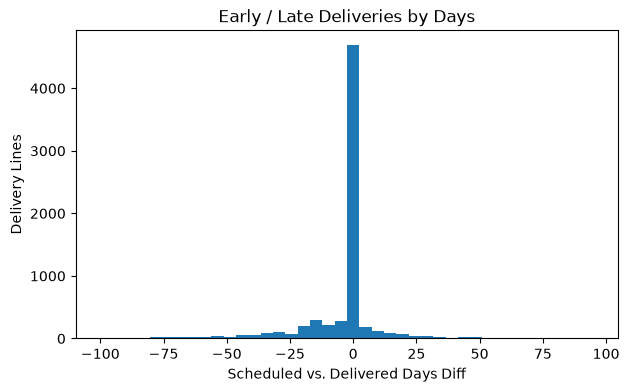

In [381]:
plt.figure(figsize=(7,4))
#sb.histplot(grouped_deliveries.delivery_diff, bins=25)
plt.hist(
    grouped_deliveries.loc[grouped_deliveries["delivery_diff"].between(-100, 100), "delivery_diff"],
    bins=40
)
plt.title("Early / Late Deliveries by Days")
plt.xlabel("Scheduled vs. Delivered Days Diff")
plt.ylabel("Delivery Lines")

# Top 10 Countries by Deliveries Performance

In [382]:
delay_perfromance = (
    grouped_deliveries[grouped_deliveries['late_days'] > 0]
    .groupby("country", as_index=False)
    .agg(
        Late_Delivery_Count = ('late_days', 'count'),
        Total_Late_Days = ('late_days', 'sum'),
        Avg_Late_Days = ('late_days', 'mean'),
        Late_Shipment_Value = ('shipment_value', 'sum')
    )

)

deliveries_performance = (
    grouped_deliveries.groupby("country", as_index=False)
        .agg(
        Total_Deliveries = ('late_days', 'count'),
        Total_Shipment_Value = ('shipment_value', 'sum')
        )
)

country_performance = delay_perfromance.merge(deliveries_performance, on='country')

country_performance["Late_Delivery_Rate"] = (
    country_performance['Late_Delivery_Count'] /
    country_performance['Total_Deliveries'] )
  

country_performance['Late_Value_Exposure_Rate'] = (
    country_performance['Late_Shipment_Value']
    / country_performance['Total_Shipment_Value']
  
)

country_performance = country_performance.fillna({
    'Late_Delivery_Count': 0,
    'Total_Late_Days': 0,
    'Avg_Late_Days_per_late_shipment': 0,
    'Late_Shipment_Value': 0
})

cols = ['country', 'Total_Deliveries', 'Late_Delivery_Count' ,\
        'Total_Late_Days', 'Avg_Late_Days','Late_Delivery_Rate',\
        'Total_Shipment_Value', 'Late_Shipment_Value', 'Late_Value_Exposure_Rate']
country_performance = country_performance[cols]
country_performance.sort_values('Late_Delivery_Rate', ascending=False)\
    .reset_index(drop=True)\
    .head(10)


country_performance.style.format({
    'Total_Shipment_Value': '${:,.0f}',
    'Total_Late_Days': '{:,.0f}',
    'Avg_Late_Days': '{:.1f}',
    'Late_Delivery_Count': '{:,.0f}',
    'Late_Shipment_Value': '${:,.0f}',
    'Late_Delivery_Rate': '{:.1%}',
    'Late_Value_Exposure_Rate': '{:.1%}'
})

,country,Total_Deliveries,Late_Delivery_Count,Total_Late_Days,Avg_Late_Days,Late_Delivery_Rate,Total_Shipment_Value,Late_Shipment_Value,Late_Value_Exposure_Rate
0,Benin,8,2,39,19.5,25.0%,"$787,725","$128,238",16.3%
1,Botswana,68,2,30,15.0,2.9%,"$1,632,899","$414,256",25.4%
2,Burundi,61,18,218,12.1,29.5%,"$3,351,580","$811,652",24.2%
3,Cameroon,63,4,48,12.0,6.3%,"$14,629,170","$1,850,898",12.7%
4,"Congo, DRC",113,24,"1,126",46.9,21.2%,"$5,772,336","$1,683,272",29.2%
5,Côte d'Ivoire,760,82,"1,138",13.9,10.8%,"$120,884,501","$17,476,128",14.5%
6,Dominican Republic,35,2,41,20.5,5.7%,"$3,146,477","$134,437",4.3%
7,Ethiopia,181,11,147,13.4,6.1%,"$19,146,999","$1,191,426",6.2%
8,Ghana,45,7,192,27.4,15.6%,"$6,453,281","$1,122,545",17.4%
9,Guatemala,8,1,10,10.0,12.5%,"$655,249","$180,346",27.5%


### Country Performance - Countries with at Least 30 Delivery Events

In [383]:
country_performance = country_performance[country_performance.Total_Deliveries >= 30]

top10_contries_Late_Delivery_Rate = (
    country_performance
    .sort_values("Late_Delivery_Rate", ascending=False)
    .head(10)
)

top10_contries_late_delivery_days = (
    country_performance
    .sort_values("Total_Late_Days", ascending=False)
    .head(10)
)

top10_contries_Avg_Late_Days = (
    country_performance
    .sort_values("Avg_Late_Days", ascending=False)
    .head(10)
)


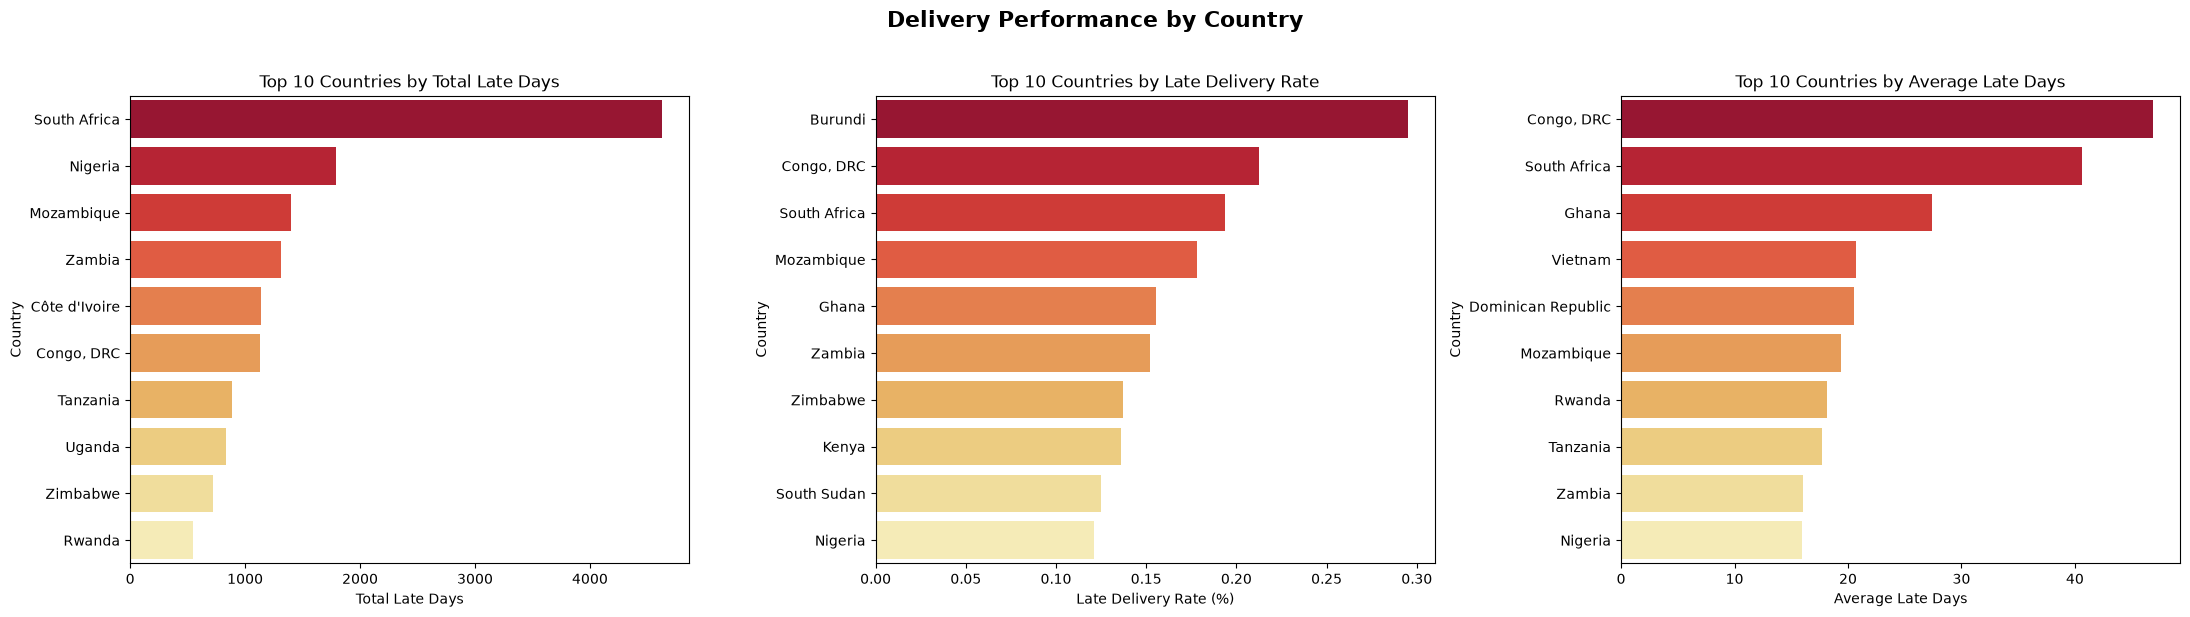

In [384]:
fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3,
    figsize=(22, 6)
)

# 1. Total late days
sb.barplot(
    data=top10_contries_late_delivery_days,
    y="country",
    x="Total_Late_Days",
    hue="country",
    palette="YlOrRd_r",
    legend=False,
    ax=ax1
)

ax1.set_title("Top 10 Countries by Total Late Days")
ax1.set_xlabel("Total Late Days")
ax1.set_ylabel("Country")


# 2. Average late days
sb.barplot(
    data=top10_contries_Late_Delivery_Rate,
    y="country",
    x="Late_Delivery_Rate",
    hue="country",
    palette="YlOrRd_r",
    legend=False,
    ax=ax2
)

ax2.set_title("Top 10 Countries by Late Delivery Rate")
ax2.set_xlabel("Late Delivery Rate (%)")
ax2.set_ylabel("Country")


# 3. Late delivery rate
sb.barplot(
    data=top10_contries_Avg_Late_Days,
    y="country",
    x="Avg_Late_Days",
    hue="country",
    palette="YlOrRd_r",
    legend=False,
    ax=ax3
)

ax3.set_title("Top 10 Countries by Average Late Days")
ax3.set_xlabel("Average Late Days")
ax3.set_ylabel("Country")

plt.suptitle(
    'Delivery Performance by Country',
    fontsize=16,
    fontweight='bold',
    y=1.02
)
plt.tight_layout()
plt.show()

### Country-Level Delivery Performance Insights

- **South Africa** has the highest cumulative delivery-delay impact, with **4,631 total late days** across **114 late deliveries** out of **589 delivery events**. Its late-delivery rate is **19.4%**, and late deliveries average **40.6 days**. This makes South Africa the highest-priority country when considering the total operational burden of late deliveries.

- **Congo, DRC** shows the most severe delivery-reliability issue among countries with a meaningful delivery volume. It has a **21.2% late-delivery rate** and an average of **46.9 late days per delayed delivery**. Although its total shipment volume is smaller than South Africa's, delays are both frequent and severe.

- **Mozambique** is a consistent risk market across multiple measures. It has **1,396 total late days**, a **17.8% late-delivery rate**, and the highest late-shipment-value exposure among the highlighted countries: **29.3%** of its shipment value is associated with late deliveries.

- **Nigeria** has the second-highest total late days, with **1,788 late days** across **112 late deliveries**. Its **12.1% late-delivery rate** is lower than South Africa's and Mozambique's, suggesting that its cumulative delay impact is largely driven by high delivery volume.

- **Zambia** has **1,316 total late days** and a **15.2% late-delivery rate** across **540 delivery events**. It should be monitored as a high-volume country with a material level of delivery unreliability.

- Countries with very small delivery volumes were excluded from the Top 10 rankings by applying a minimum threshold of **more than 30 delivery events**. This avoids drawing strong conclusions from countries where one or two delayed deliveries could distort the late-delivery rate.

### Recommended Actions

1. Prioritize root-cause analysis for South Africa, Congo, DRC, and Mozambique, focusing on the reasons behind sustained late-delivery risk.
2. Use South Africa as the primary market for reducing cumulative delay exposure because of its high number of delayed deliveries and total late days.
3. Investigate Congo, DRC for severe late-delivery cases, since delayed shipments take the longest on average.
4. Monitor Mozambique closely for financial exposure, as a substantial share of shipment value is associated with late deliveries.
5. Review Nigeria and Zambia through a volume-adjusted lens, as their cumulative late days are driven partly by a larger number of delivery events.

# Top 10 Vendors by Deliveries Performance

In [385]:

vendor_delays = (
    grouped_deliveries[grouped_deliveries['late_days'] > 0]
    .groupby("vendor", as_index=False)
    .agg(
        Total_Late_Days = ('late_days', 'sum'),
        Avg_Late_Days = ('late_days' , 'mean'),
        Late_Delivery_Count = ('late_days' , 'count'),   
        Late_Shipment_Value = ('shipment_value', 'sum') 
    )
)

vendor_stats = (
    grouped_deliveries
        .groupby("vendor")
        .agg(
            Total_Deliveries = ('late_days' , 'count'),  
            Total_Shipment_Value = ('shipment_value', 'sum')
        )
    )

vendor_performance = vendor_stats.merge(vendor_delays, on='vendor')

vendor_performance = vendor_performance.fillna({
    'Late_Delivery_Count': 0,
    'Total_Late_Days': 0,
    'Avg_Late_Days': 0,
    'Late_Shipment_Value': 0
})

vendor_performance['Late_Value_Exposure_Rate'] = (
    vendor_performance['Late_Shipment_Value'] /
    vendor_performance['Total_Shipment_Value']

)

vendor_performance["Late_Delivery_Rate"] = (
    vendor_performance['Late_Delivery_Count'] /
    vendor_performance['Total_Deliveries'] )

cols = ['vendor', 'Total_Deliveries', 'Late_Delivery_Count' ,\
        'Total_Late_Days', 'Avg_Late_Days','Late_Delivery_Rate',\
        'Total_Shipment_Value', 'Late_Shipment_Value', 'Late_Value_Exposure_Rate']
vendor_performance = vendor_performance[cols]
vendor_performance.sort_values('Late_Delivery_Rate', ascending=False)\
    .reset_index(drop=True)\
    .head(10)

vendor_performance.style.format({
    'Total_Shipment_Value': '${:,.0f}',
    'Total_Late_Days': '{:,.0f}',
    'Avg_Late_Days': '{:.1f}',
    'Late_Delivery_Count': '{:,.0f}',
    'Late_Shipment_Value': '${:,.0f}',
    'Late_Delivery_Rate': '{:.1%}',
    'Late_Value_Exposure_Rate': '{:.1%}'
})



,vendor,Total_Deliveries,Late_Delivery_Count,Total_Late_Days,Avg_Late_Days,Late_Delivery_Rate,Total_Shipment_Value,Late_Shipment_Value,Late_Value_Exposure_Rate
0,ABBVIE LOGISTICS (FORMERLY ABBOTT LOGISTICS BV),335,4,111,27.8,1.2%,"$29,448,061","$238,048",0.8%
1,ASPEN PHARMACARE,35,1,36,36.0,2.9%,"$3,164,725","$120,240",3.8%
2,Abbott GmbH & Co. KG,21,1,48,48.0,4.8%,"$2,342,400","$120,000",5.1%
3,Aurobindo Pharma Limited,546,94,"3,343",35.6,17.2%,"$91,383,711","$18,656,561",20.4%
4,BIO-RAD LABORATORIES (FRANCE),28,4,60,15.0,14.3%,"$1,493,378","$176,656",11.8%
5,"CHEMBIO DIAGNOSTIC SYSTEMS, INC.",109,1,24,24.0,0.9%,"$8,520,710","$310,500",3.6%
6,CIPLA LIMITED,169,23,941,40.9,13.6%,"$39,658,695","$6,398,240",16.1%
7,EMCURE PHARMACEUTICALS LTD,40,2,57,28.5,5.0%,"$5,756,840","$661,237",11.5%
8,HETERO LABS LIMITED,201,2,9,4.5,1.0%,"$42,881,567","$559,674",1.3%
9,"JSI R&T INSTITUTE, INC.",8,1,95,95.0,12.5%,"$250,690",$58,0.0%


### Vendor Performance - Vendors with at Least 30 Delivery Events

In [386]:
vendor_performance = vendor_performance[vendor_performance['Total_Deliveries'] > 30]

top10_vendors_Late_Delivery_Rate = (
    vendor_performance
    .sort_values("Late_Delivery_Rate", ascending=False)
    .head(10)
)

top10_vendors_late_delivery_days = (
    vendor_performance
    .sort_values("Total_Late_Days", ascending=False)
    .head(10)
)

top10_vendors_Avg_Late_Days_per_late_shipment = (
    vendor_performance
    .sort_values("Avg_Late_Days", ascending=False)
    .head(10)
)

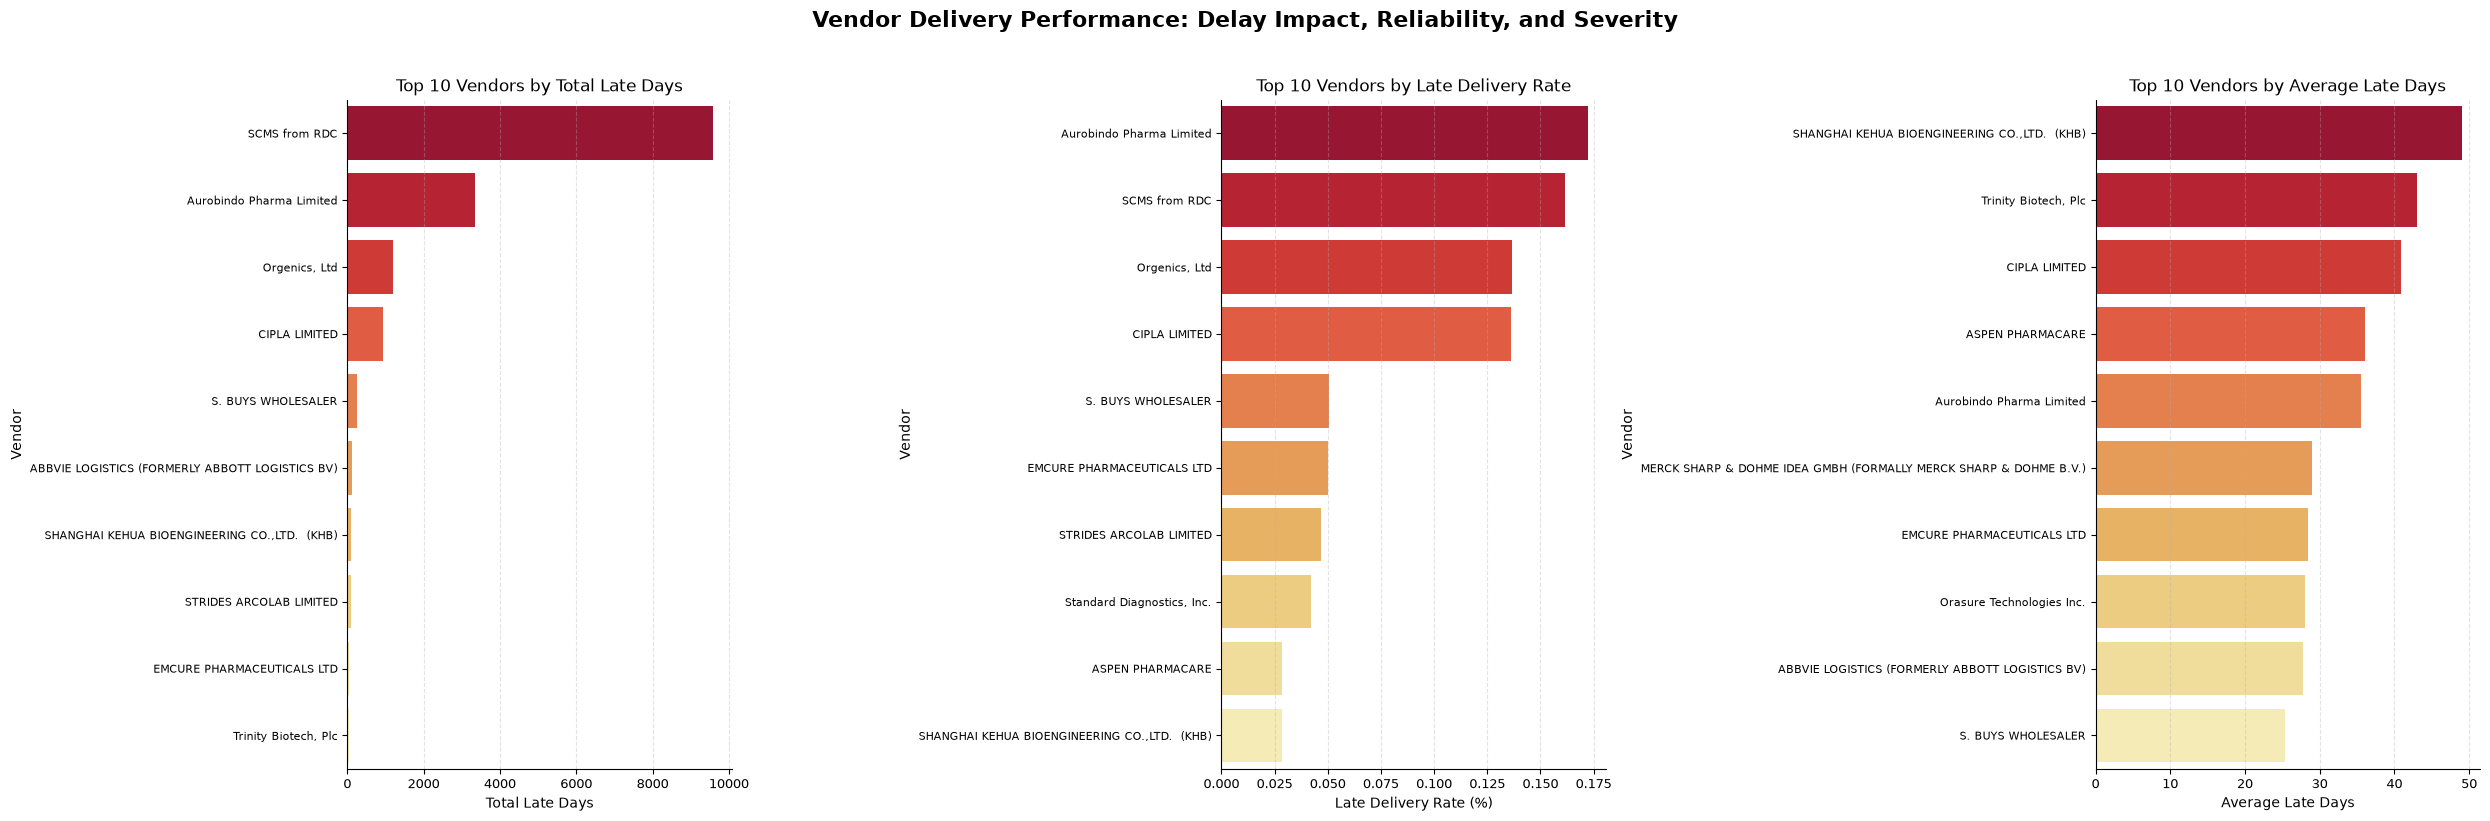

In [387]:
fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3,
    figsize=(25, 8)
)

# 1. Total late days
sb.barplot(
    data=top10_vendors_late_delivery_days,
    y="vendor",
    x="Total_Late_Days",
    hue="vendor",
    palette="YlOrRd_r",
    legend=False,
    ax=ax1
)

ax1.set_title("Top 10 Vendors by Total Late Days")
ax1.set_xlabel("Total Late Days")
ax1.set_ylabel("Vendor")


# 2. Average late days
sb.barplot(
    data=top10_vendors_Late_Delivery_Rate,
    y="vendor",
    x="Late_Delivery_Rate",
    hue="vendor",
    palette="YlOrRd_r",
    legend=False,
    ax=ax2
)

ax2.set_title("Top 10 Vendors by Late Delivery Rate")
ax2.set_xlabel("Late Delivery Rate (%)")
ax2.set_ylabel("Vendor")


# 3. Late delivery rate
sb.barplot(
    data=top10_vendors_Avg_Late_Days_per_late_shipment,
    y="vendor",
    x="Avg_Late_Days",
    hue="vendor",
    palette="YlOrRd_r",
    legend=False,
    ax=ax3
)

ax3.set_title("Top 10 Vendors by Average Late Days")
ax3.set_xlabel("Average Late Days")
ax3.set_ylabel("Vendor")

for ax in [ax1, ax2, ax3]:
    ax.grid(axis='x', linestyle='--', alpha=0.35)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=8)
    ax.tick_params(axis='x', labelsize=9)

plt.suptitle(
    'Vendor Delivery Performance: Delay Impact, Reliability, and Severity',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

### Vendor Delivery Performance Insights

- **SCMS from RDC** has the largest cumulative delay impact by a substantial margin, with nearly 10,000 total late days. This indicates a major concentration of overall delivery-delay exposure.

- **Aurobindo Pharma Limited** has the highest late-delivery rate among vendors with at least 30 delivery events. It also has the second-highest cumulative late days, making it a priority vendor for delivery-performance improvement.

- **Organics, Ltd** and **CIPLA LIMITED** also show elevated late-delivery rates, indicating lower delivery reliability relative to other high-volume vendors.

- **Shanghai Kehua Bioengineering (KHB)** has the highest average late days. While its late-delivery rate is lower than several other vendors, delays are especially severe when they occur.

- **Trinity Biotech**, **CIPLA LIMITED**, and **ASPEN PHARMACARE** also show high average late days, suggesting that their delayed deliveries require root-cause investigation for severe delay events.

- Vendor performance should be evaluated across all three dimensions: cumulative delay impact, late-delivery rate, and average delay severity. A vendor with a high rate is not necessarily the vendor with the highest total business impact.

## Shipment Complexity and Delivery Performance

This section evaluates whether delivery complexity is associated with increased late-delivery risk.

A delivery is considered more complex when it contains line items from multiple manufacturing sites, multiple products, or multiple line items.

In [388]:
grouped_deliveries['Shipment_Complexity'] = (grouped_deliveries['number_of_manufacturing_sites'] > 1).astype(int)

a = ( 
    grouped_deliveries
    .groupby('Shipment_Complexity')['shipment_value']
    .agg(
        Total_Deliveries = 'count',
        Total_Shipment_Value = 'sum'
    )
)

b = ( 
    grouped_deliveries[grouped_deliveries['late_days'] > 0]
    .groupby('Shipment_Complexity')
    .agg(
        Total_Late_Days = ('late_days', 'sum'),
        Avg_Late_Days = ('late_days' , 'mean'),
        Late_Delivery_Count = ('late_days' , 'count'),   
        Late_Shipment_Value = ('shipment_value', 'sum') 
            )
)

a = a.merge(b, on='Shipment_Complexity')

a['Late_Delivery_Rate'] = (a['Late_Delivery_Count'] / a['Total_Deliveries']).round(2)
a['Late_Value_Exposure_Rate'] = (a['Late_Shipment_Value'] / a['Total_Shipment_Value']).round(2)


site_complexity_performance = (
a.reset_index()
    .replace({
    0: 'Single Manufacturing Site',
    1: 'Multiple Manufacturing Sites'
    })
)

site_complexity_performance.style.format({
    'Total_Shipment_Value': '${:,.0f}',
    'Total_Late_Days': '{:,.0f}',
    'Avg_Late_Days': '{:.1f}',
    'Late_Delivery_Count': '{:,.0f}',
    'Late_Shipment_Value': '${:,.0f}',
    'Late_Delivery_Rate': '{:.1%}',
    'Late_Value_Exposure_Rate': '{:.1%}'
})

,Shipment_Complexity,Total_Deliveries,Total_Shipment_Value,Total_Late_Days,Avg_Late_Days,Late_Delivery_Count,Late_Shipment_Value,Late_Delivery_Rate,Late_Value_Exposure_Rate
0,Single Manufacturing Site,6161,"$1,132,950,675","13,371",20.3,659,"$160,979,350",11.0%,14.0%
1,Multiple Manufacturing Sites,879,"$494,633,783","2,750",18.6,148,"$98,054,921",17.0%,20.0%


### Manufacturing-Site Complexity Insights

- Deliveries involving multiple manufacturing sites represent 879 of 7,040 delivery events, or approximately 12.5% of all shipments.

- Multiple-site deliveries have a higher late-delivery rate than single-site deliveries: approximately 16.8% compared with 10.7%.

- Multiple-site deliveries also have higher late-shipment-value exposure: approximately 19.8% of shipment value is associated with late deliveries, compared with 14.2% for single-site deliveries.

- Average delay severity is slightly lower for multiple-site deliveries, at approximately 18.6 late days compared with 20.3 late days for single-site deliveries.

- The findings suggest that multi-site coordination increases the likelihood of delivery delays, even when the average duration of individual delay events is not higher.

### Operational Recommendation

Multi-site deliveries should be identified during planning and monitored as a higher-risk shipment category. Potential mitigation actions include earlier planning, additional schedule buffers, and clearer coordination across manufacturing sites.

# Final Findings and Recommendations

## Executive Summary

This analysis evaluated historical supply-chain delivery performance at the delivery-event level. The raw dataset contained 10,324 line-item records, which were consolidated into 7,040 delivery events to avoid inflating delivery KPIs for shipments with multiple product lines.

Overall delivery performance was strong, with an On-Time Delivery Rate of 88.5%. However, 807 delivery events were late, representing an 11.5% late-delivery rate. These delayed deliveries accumulated 16,121 late days, with an average delay of 20.0 days per late delivery.

The analysis identified delivery-risk concentration across countries, vendors, and shipment complexity:

- **South Africa** had the highest cumulative delivery-delay impact, with 4,631 total late days across 114 late deliveries.
- **Congo, DRC** showed a major delivery-reliability risk, with a 21.2% late-delivery rate and an average of 46.9 late days per delayed delivery.
- **Mozambique** showed high late-shipment-value exposure, with 29.3% of shipment value associated with late deliveries.
- **SCMS from RDC** had the highest cumulative vendor delay impact, with nearly 10,000 total late days.
- **Aurobindo Pharma Limited** had the highest late-delivery rate among the analyzed high-volume vendors and the second-highest cumulative delay impact.
- Delivery events involving multiple manufacturing sites were more likely to be late than single-site deliveries, with an approximately 16.8% late-delivery rate compared with 10.7% for single-site deliveries.
- Multi-site shipments also had higher late-shipment-value exposure, approximately 19.8% compared with 14.2% for single-site deliveries.

These findings indicate that the most important opportunities are not only reducing the number of late deliveries, but also prioritizing high-impact countries, vendors, and complex delivery events.

## Recommendations

1. **Prioritize high-impact country interventions.**  
   Focus first on South Africa because it has the highest cumulative delay burden. Review local delivery routes, lead times, customs processes, and delivery handoffs to reduce total late days.

2. **Investigate severe delivery-delay markets.**  
   Conduct root-cause analysis for Congo, DRC, where delayed deliveries are both relatively frequent and severe. Review the specific delayed delivery events, shipment modes, delivery routes, and planning assumptions.

3. **Manage vendor delivery risk through segmented performance reviews.**  
   Prioritize SCMS from RDC for reducing total late-day exposure and Aurobindo Pharma Limited for improving late-delivery reliability. Vendor reviews should combine shipment volume, late-delivery rate, total late days, and average delay severity.

4. **Flag multi-site shipments as high-risk during planning.**  
   Delivery events involving multiple manufacturing sites have a higher late-delivery rate and higher shipment-value exposure. Assign additional planning time, coordination checkpoints, and schedule buffers to these shipments.

5. **Create an early-warning delivery dashboard.**  
   Monitor On-Time Delivery Rate, Late Delivery Rate, Total Late Days, Late Shipment Value, and Late Value Exposure by country, vendor, and delivery complexity. This would allow operations teams to identify at-risk shipments before the scheduled delivery date.

6. **Use volume-adjusted performance thresholds.**  
   Interpret late-delivery rates together with delivery volume. Countries or vendors with very small delivery populations may show high rates that are not yet strong evidence of broad operational risk.

## Limitations

- The analysis is based on historical data and should not be interpreted as current performance of the countries, vendors, or organizations named in the dataset.

- The analysis identifies associations, not causality. For example, multi-site deliveries are associated with higher late-delivery risk, but the dataset does not prove that multi-site coordination is the direct cause of delay.

- Some delivery events include products from multiple manufacturing sites. Therefore, delivery-level delay outcomes should not be assigned to a single manufacturing site without building a separate delivery-event-by-site model.

- Freight cost and weight fields contain mixed numeric and text-based business values, such as `Invoiced Separately` and `Weight Captured Separately`. These fields require additional cleaning before reliable logistics-cost or weight analysis.

- Late-delivery-rate rankings were filtered using a minimum delivery-volume threshold where appropriate. Small delivery populations can produce unstable percentage-based performance results.